In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score

In [24]:
df = pd.read_csv("./find-polynomial/train.csv")
x1 = df[["x1"]].values.squeeze(axis=1)
x2 = df[["x2"]].values.squeeze(axis=1)
x = df[["x1", "x2"]].values

y = df["y"].values


In [25]:
df.describe()

,x1,x2,y
count,800.000000,800.000000,8.000000e+02
mean,9.984985,41.981982,-2.830521e+09
std,34.697357,41.636829,5.480539e+09
min,-50.000000,-30.000000,-2.459204e+10
25%,-20.007508,5.990991,-2.501036e+09
50%,9.984985,41.981982,-1.374909e+08
75%,39.977477,77.972973,-1.076735e+07
max,69.969970,113.963964,-3.609140e+05


<AxesSubplot: >

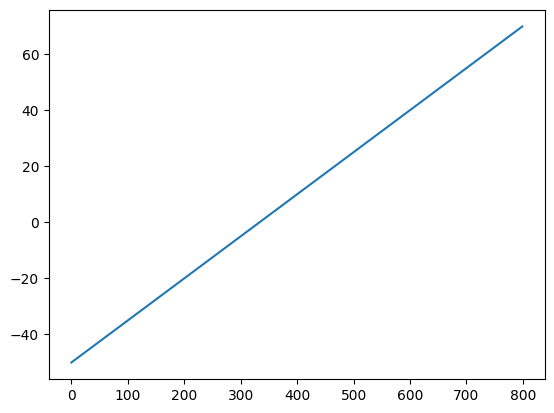

In [26]:
plt.close("all")
df['x1'].plot()

<AxesSubplot: >

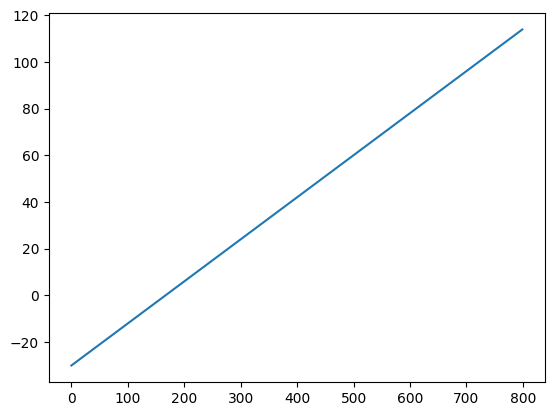

In [27]:
df['x2'].plot()

<AxesSubplot: >

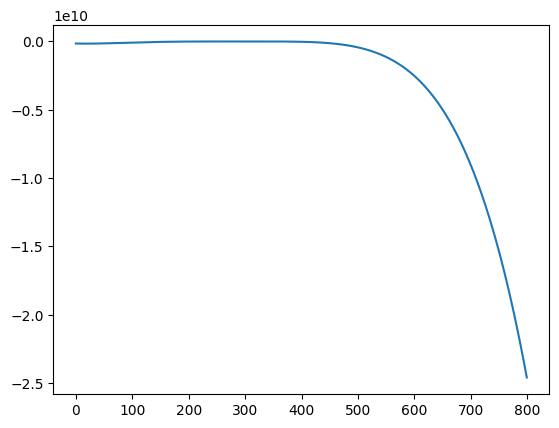

In [28]:
df['y'].plot()

<AxesSubplot: >

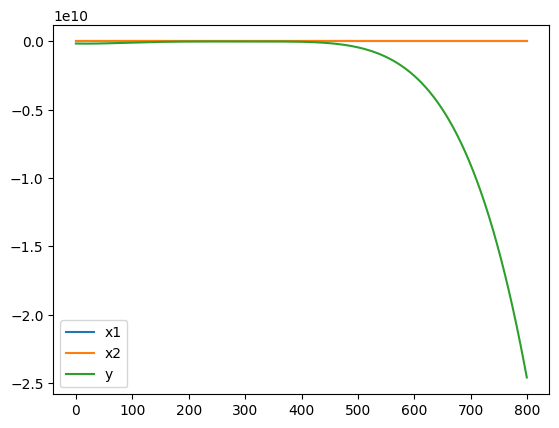

In [29]:
df.plot()

In [30]:
# Feature engineering
X = np.column_stack([
# Best one till now
    # x1**4,
    # x2**4,
    # x1**3 * x2,
    # x1**5,
    # x2**5,
    # x1**4 * x2**1,
    # x1**3 * x2**2,
# Test
    x1**4,
    x2**4,
    x1**3 * x2,
    x1**5,
    x2**5,
    x1**4 * x2**1,
    x1**3 * x2**2,
    # x1**3 * x2**3,

 ])

In [31]:
model = Ridge(alpha=568.9866029018293)

# Define k-fold cross-validation
kf = KFold(n_splits=3, shuffle=True, random_state=12)


In [32]:
model = Ridge(alpha=568.9866029018293)

# Define k-fold cross-validation
kf = KFold(n_splits=3, shuffle=True, random_state=12)
scores = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error")
mean_score = scores.mean()

print("Best CV MSE:", mean_score)


Best CV MSE: 3.869985135305452


/home/suhaib/miniconda3/envs/Ditto/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.78691e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/suhaib/miniconda3/envs/Ditto/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.47342e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/suhaib/miniconda3/envs/Ditto/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.22081e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [33]:
# Custom scoring functions
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

In [34]:
# Run CV
mse_scores = cross_val_score(model, X, y, cv=kf, scoring=mse_scorer)
r2_scores = cross_val_score(model, X, y, cv=kf, scoring=r2_scorer)

/home/suhaib/miniconda3/envs/Ditto/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.78691e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/suhaib/miniconda3/envs/Ditto/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.47342e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/suhaib/miniconda3/envs/Ditto/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.22081e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/suhaib/miniconda3/envs/Ditto/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.78691e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True

In [35]:
print("=== Ridge Regression with 5-Fold CV ===")
print("MSE per fold:", -mse_scores)
print("Mean MSE:", -mse_scores.mean())


=== Ridge Regression with 5-Fold CV ===
MSE per fold: [4.12747771 3.6058173  3.8766604 ]
Mean MSE: 3.869985135305452


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


/home/suhaib/miniconda3/envs/Ditto/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=6.98104e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [38]:
model.coef_

array([-1.22698524e+02,  2.01342591e+01,  9.17999999e+02, -3.27358706e+00,
       -5.55567897e-01,  4.22666815e+01, -3.60000000e+01])

In [39]:
model.intercept_

-3375446.978196621

In [40]:
print("=== Linear Features ===")
print("MSE:", mean_squared_error(y_test, y_pred))

=== Linear Features ===
MSE: 3.6168560203417295


(160,)


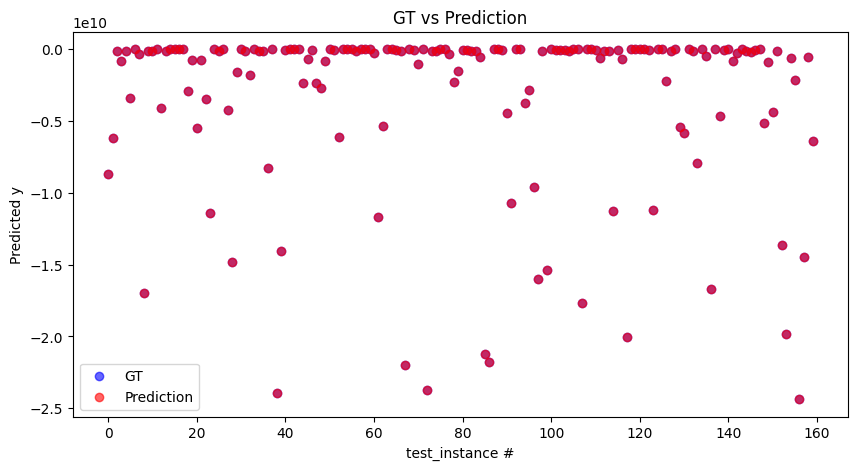

In [41]:
plt.figure(figsize=(10,5))
print(y_test.shape)
plt.scatter(np.arange(y_test.shape[0]),y_test, label="GT", alpha=0.6, color='b')
plt.scatter(np.arange(y_test.shape[0]),y_pred, label="Prediction", alpha=0.6,color='r')
plt.xlabel("test_instance #")
plt.ylabel("Predicted y")
plt.legend()
plt.title("GT vs Prediction")
plt.show()

In [42]:
df_test = pd.read_csv("./test.csv")
df_test.head()

FileNotFoundError: [Errno 2] No such file or directory: './test.csv'

In [ ]:
x1f = df_test[["x1"]].squeeze(1)
x2f = df_test[["x2"]].squeeze(1)
X_test_f = np.column_stack([
    x1f**4,
    x2f**4,
    x1f**3 * x2f,
    x1f**5,
    x2f**5,
    x1f**4 * x2f**1,
    x1f**3 * x2f**2,
])

In [ ]:
y_test_f = model.predict(X_test_f)
y_test_f.shape

(200,)

In [ ]:
submission = pd.DataFrame(np.vstack([np.arange(200),y_test_f]).T,columns=["id","y"])
submission[["id"]] = submission[["id"]].astype(int)
submission.to_csv('./submission.csv', index=False)